In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/16-diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

for col in cols:
    print(col, (df[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [12]:
df.shape

(768, 9)

In [14]:
df[col] = df[col].replace(0, np.nan)

In [16]:
df[col] = df[col].fillna(df[col].median())

In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [18]:
X = df.drop("Outcome", axis = 1)
y = df["Outcome"]


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 42, test_size= 0.2, stratify=y
)

In [21]:
model = AdaBoostClassifier()

In [23]:
model.fit(X_train, y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [24]:
y_pred = model.predict(X_test)

In [26]:
print(f'Model accuracy score with default decision-trees : {accuracy_score(y_test, y_pred)}')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("train_overfit: ", model.score(X_train, y_train))

Model accuracy score with default decision-trees : 0.7662337662337663
[[85 15]
 [21 33]]
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       100
           1       0.69      0.61      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154

train_overfit:  0.8013029315960912


Hiperparametreli Adaboost Classifier

In [54]:
param_grid = {
    "n_estimators": [50, 100, 200,500,700,1000],
    "learning_rate": [0.01, 0.1, 0.5, 1],
}

In [55]:
grid = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=param_grid,
    scoring="recall",
    cv=5
)

In [56]:
grid.fit(X_train, y_train)

,estimator,AdaBoostClass...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,estimator,None


In [57]:
y_pred_grid = grid.predict(X_test)

In [61]:
print(f'Model accuracy score with default decision-trees : {accuracy_score(y_test, y_pred_grid)}')
print(confusion_matrix(y_test, y_pred_grid))
print(classification_report(y_test, y_pred_grid))
print("train_overfit: ", grid.score(X_train, y_train))

Model accuracy score with default decision-trees : 0.7792207792207793
[[86 14]
 [20 34]]
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       100
           1       0.71      0.63      0.67        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.78      0.78      0.78       154

train_overfit:  0.6962616822429907


In [62]:
grid.best_estimator_

,estimator,None
,n_estimators,500
,learning_rate,1
,algorithm,'deprecated'
,random_state,42


In [63]:
grid.best_score_

np.float64(0.5796234772978959)

In [65]:
y_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]

In [66]:
y_pred_035 = (y_proba >= 0.35).astype(int)

In [68]:
print(f'Model accuracy score with default decision-trees : {accuracy_score(y_test, y_pred_035)}')
print(confusion_matrix(y_test, y_pred_035))
print(classification_report(y_test, y_pred_035))
print("train_overfit: ", grid.score(X_train, y_train))

Model accuracy score with default decision-trees : 0.37012987012987014
[[ 3 97]
 [ 0 54]]
              precision    recall  f1-score   support

           0       1.00      0.03      0.06       100
           1       0.36      1.00      0.53        54

    accuracy                           0.37       154
   macro avg       0.68      0.52      0.29       154
weighted avg       0.77      0.37      0.22       154

train_overfit:  0.6962616822429907


In [71]:
thresholds = [0.40, 0.45]

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    print("Threshold:", t)
    print(confusion_matrix(y_test, y_pred_t))
    print(classification_report(y_test, y_pred_t))
    print("-" * 50)

Threshold: 0.4
[[16 84]
 [ 0 54]]
              precision    recall  f1-score   support

           0       1.00      0.16      0.28       100
           1       0.39      1.00      0.56        54

    accuracy                           0.45       154
   macro avg       0.70      0.58      0.42       154
weighted avg       0.79      0.45      0.38       154

--------------------------------------------------
Threshold: 0.45
[[52 48]
 [ 4 50]]
              precision    recall  f1-score   support

           0       0.93      0.52      0.67       100
           1       0.51      0.93      0.66        54

    accuracy                           0.66       154
   macro avg       0.72      0.72      0.66       154
weighted avg       0.78      0.66      0.66       154

--------------------------------------------------


In [74]:
best_model = grid.best_estimator_

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
5,BMI,0.242235
6,DiabetesPedigreeFunction,0.231372
1,Glucose,0.189458
4,Insulin,0.123609
7,Age,0.087213
3,SkinThickness,0.053148
2,BloodPressure,0.047232
0,Pregnancies,0.025732


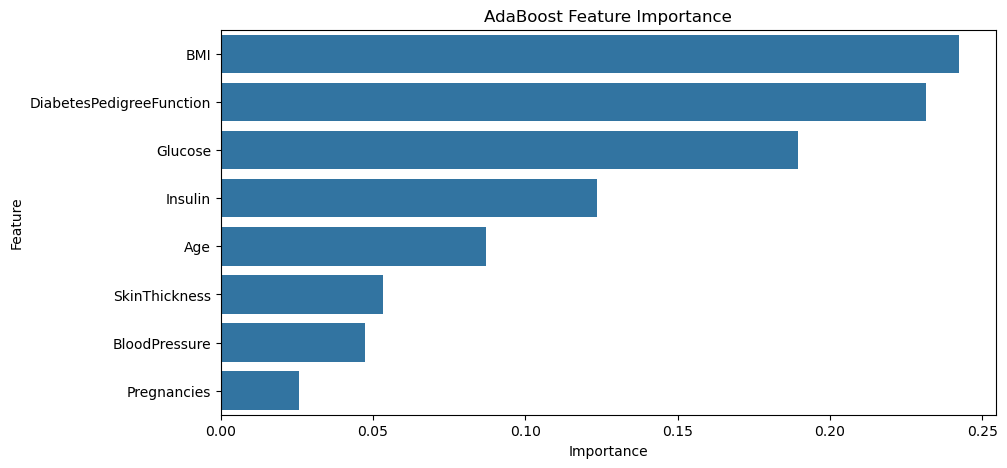

In [75]:
plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("AdaBoost Feature Importance")
plt.show()


### Diğer Classification Modelleri
##### Random Forest

In [77]:
from sklearn.ensemble import RandomForestClassifier

In [91]:
random = RandomForestClassifier(
    class_weight="balanced",
    random_state= 42
)

In [92]:
random.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [93]:
y_pred_rf = random.predict(X_test)

In [94]:
print(f'Model accuracy score with default decision-trees : {accuracy_score(y_test, y_pred_rf)}')
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("train_overfit: ", grid.score(X_train, y_train))

Model accuracy score with default decision-trees : 0.7532467532467533
[[84 16]
 [22 32]]
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       100
           1       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154

train_overfit:  0.6962616822429907


In [96]:
param_rf = {
    "n_estimators": [300, 500],
    "max_depth": [2,3,4],
    "min_samples_split": [5,10,20],
    "min_samples_leaf": [1,2,5],
}

In [97]:
grid_rf = GridSearchCV(
    estimator= random,
    param_grid= param_rf,
    cv= 5,
    scoring= "recall"
)

In [98]:
grid_rf.fit(X_train, y_train)
y_pred_rf = grid_rf.predict(X_test)

In [99]:
print(f'Model accuracy score with default decision-trees : {accuracy_score(y_test, y_pred_rf)}')
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("train_overfit: ", grid_rf.score(X_train, y_train))

Model accuracy score with default decision-trees : 0.7532467532467533
[[75 25]
 [13 41]]
              precision    recall  f1-score   support

           0       0.85      0.75      0.80       100
           1       0.62      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154

train_overfit:  0.822429906542056
